In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
    subjects=[1],
    return_epochs=True
)


Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_3977/489331373.py:7: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(4200, 8, 26)

In [20]:
from hoda.hoda import BTTDA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import warnings
warnings.filterwarnings("ignore")

n_blocks=8
bttda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(            
            rank=None,
            max_iter=128,
            tol=1e-16,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
            lasso=False,
            prune=True,
    ),
    deflate_transform=False,
    keep_train_info=True,
    verbose=True)                   

bttda.fit(X,y)

Fitting block 1/8...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [1, 1] ...

Fitting block 2/8...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [3, 3] ...

Fitting block 3/8...
Initializing factors...
Fitting discriminative Tucker model...


...

  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [1, 1] ...

Fitting block 8/8...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [1, 1] ...



KeyError: 'block'

In [21]:
bttda.train_info_

,mse,explained,f_stat
block,,,
0,6.960469e-11,0.040813,0.392870
2,6.916157e-11,0.097136,0.041944
7,6.702797e-11,0.168706,0.026622
6,6.714336e-11,0.216386,0.025191
5,6.806770e-11,0.172265,0.024905
3,6.780125e-11,0.175759,0.024559
1,6.922096e-11,0.091848,0.023586
4,6.741412e-11,0.189462,0.007806


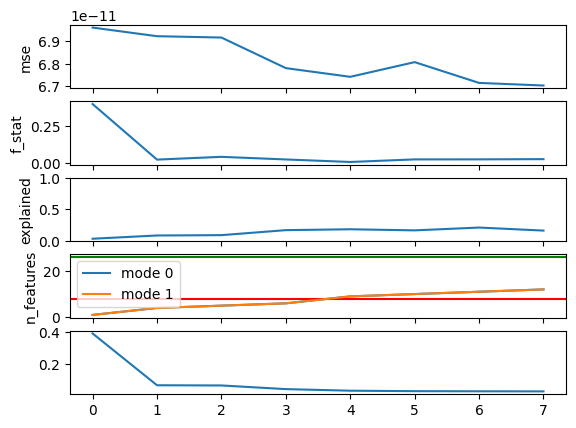

In [23]:
import seaborn as sns
import math
from hoda.hoda import f_multiway

if bttda.keep_train_info:
    fig, axs = plt.subplots(5,1, sharex=True)
    sns.lineplot(data=bttda.train_info_,  x="block", y="mse", ax=axs[0])
    #axs[0].set_ylim([0,None])
    sns.lineplot(data=bttda.train_info_,  x="block", y="f_stat", ax=axs[1])
    sns.lineplot(data=bttda.train_info_,  x="block", y="explained", ax=axs[2])
    axs[2].set_ylim([0,1])
    #axs[2].axhline(bttda.var_thresh, color='red', linestyle='--')
    n_features_m0 = [bttda.n_features(b+1, 0) for b in range(n_blocks)]
    n_features_m1 = [bttda.n_features(b+1, 1) for b in range(n_blocks)]
    axs[3].plot(n_features_m0, label='mode 0')
    axs[3].axhline(X.shape[1], color='red')
    axs[3].plot(n_features_m1, label='mode 1')
    axs[3].axhline(X.shape[2], color='green')
    axs[3].legend()
    axs[3].set_ylabel('n_features')
    f_stat = [f_multiway(bttda.transform(X, n_blocks=b+1),y) for b in range(n_blocks)]
    axs[4].plot(f_stat)

Not setting metadata
700 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


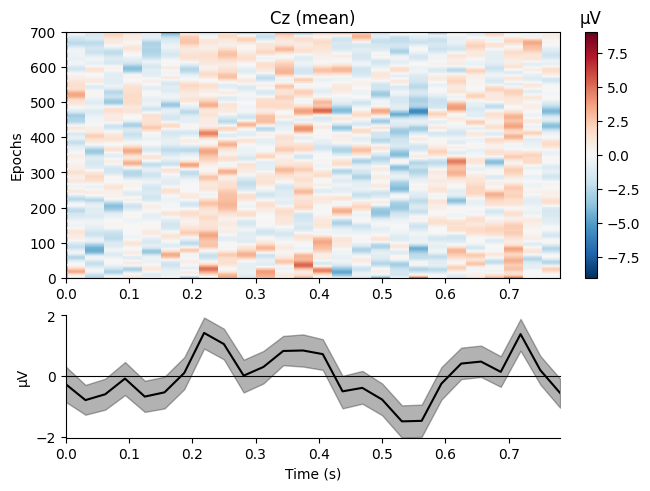

No projector specified for this dataset. Please consider the method self.add_proj.


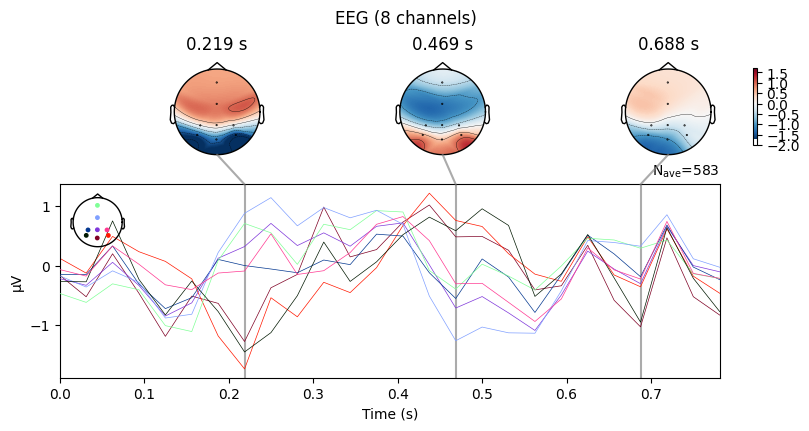

In [24]:
from mne import combine_evoked

image_args=dict(picks=['Cz'], combine='mean', sigma=8)
epochs['Target'].plot_image(**image_args)

joint_args=dict(ts_args=dict(ylim=dict(eeg=
                                       #[-50,50]
                                       None
                                      )))
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
_ = contrast.plot_joint(**joint_args)

No projector specified for this dataset. Please consider the method self.add_proj.


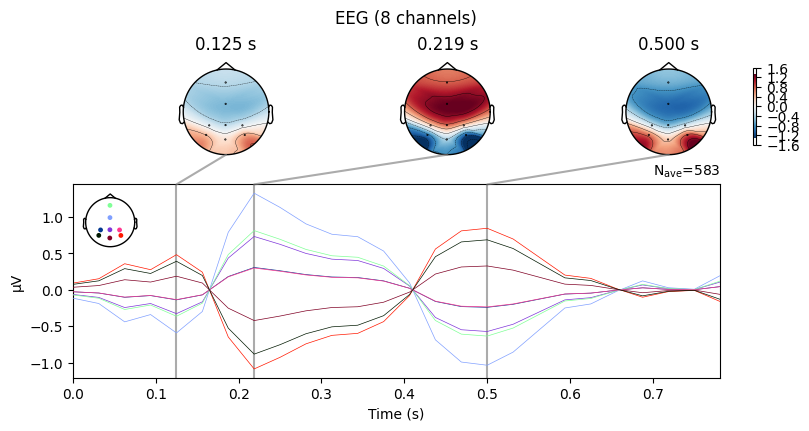

No projector specified for this dataset. Please consider the method self.add_proj.


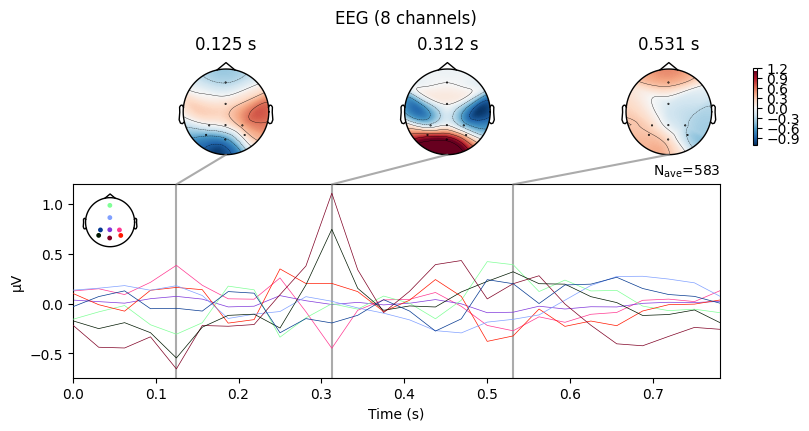

No projector specified for this dataset. Please consider the method self.add_proj.


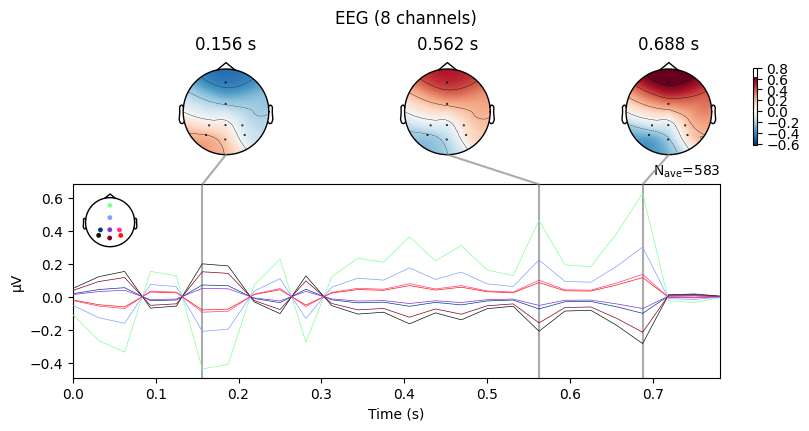

No projector specified for this dataset. Please consider the method self.add_proj.


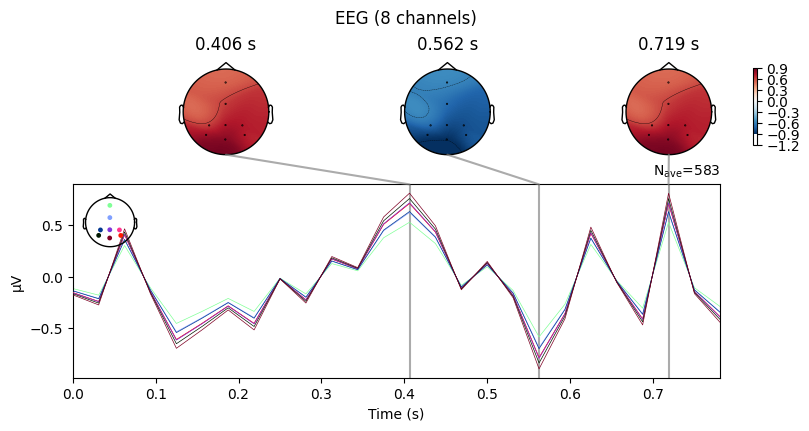

No projector specified for this dataset. Please consider the method self.add_proj.


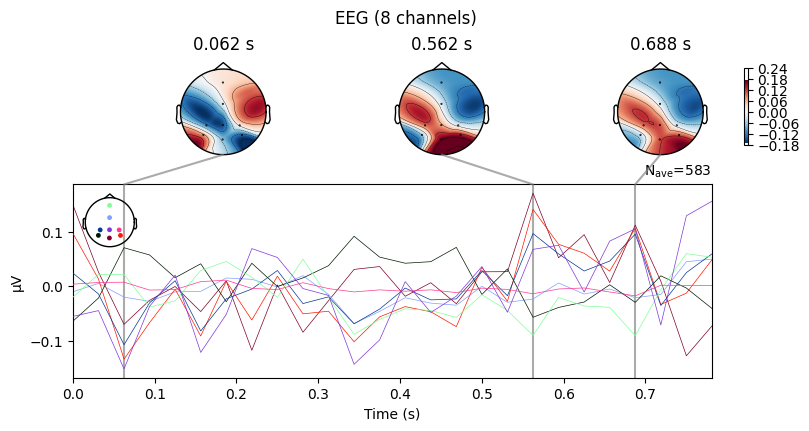

No projector specified for this dataset. Please consider the method self.add_proj.


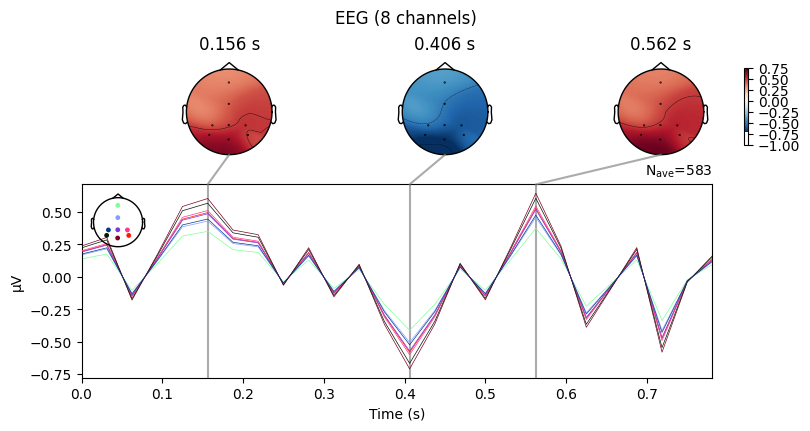

No projector specified for this dataset. Please consider the method self.add_proj.


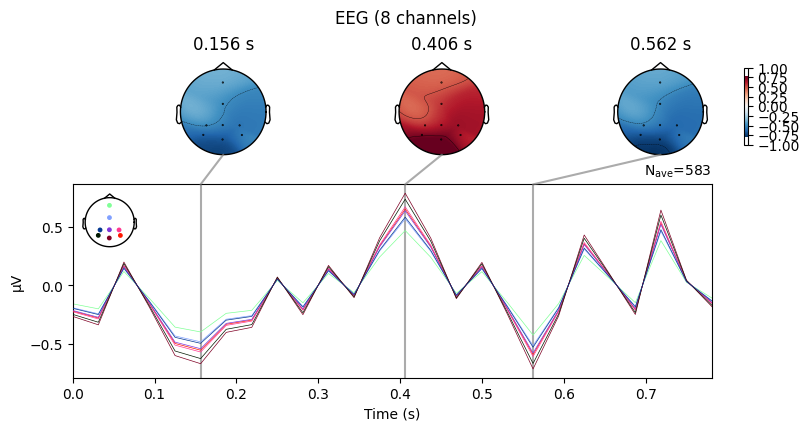

No projector specified for this dataset. Please consider the method self.add_proj.


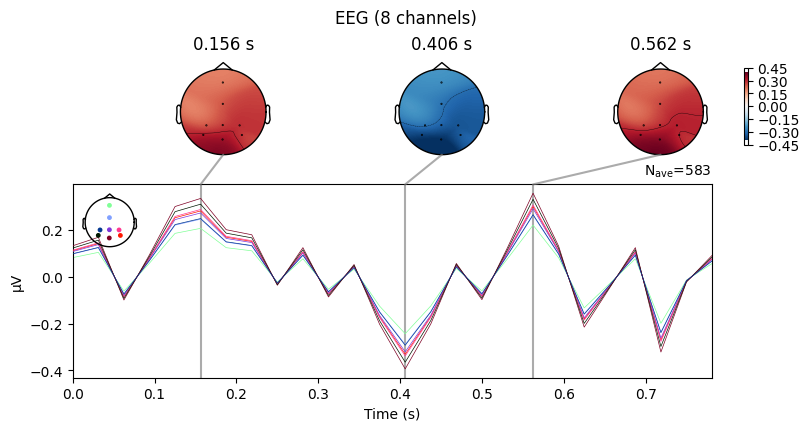

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


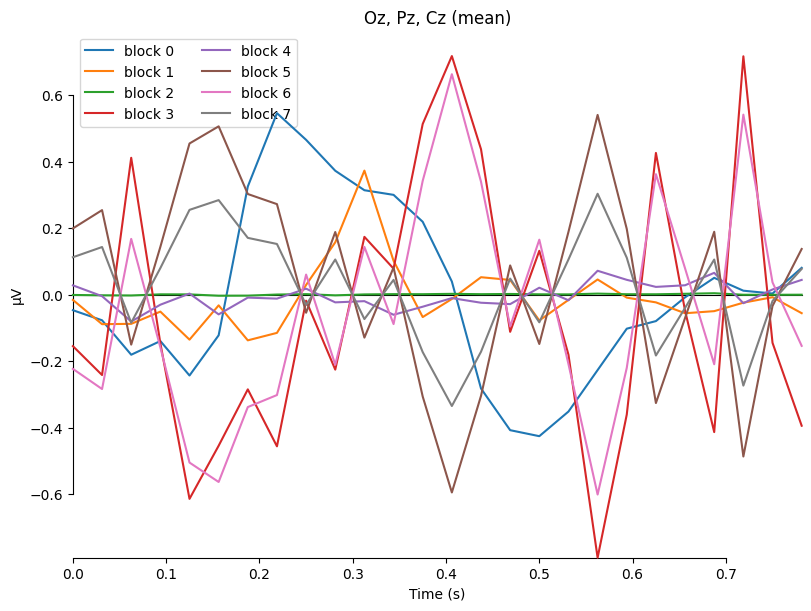

[<Figure size 800x600 with 1 Axes>]

In [8]:
from mne import combine_evoked
from hoda.hoda import mse
from mne.viz import plot_compare_evokeds
import numpy as np

epochs_defl = epochs.copy()
epochs_rec = epochs.copy()
epochs_rec._data = np.zeros_like(epochs_rec.get_data())
evokeds = dict()
for b in range(min(len(bttda.blocks_),10)):
    epochs_block_rec = epochs.copy()
    epochs_block_rec._data = tl.to_numpy(bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_defl.get_data())))
    epochs_defl._data -= epochs_block_rec._data
    epochs_rec._data += epochs_block_rec._data
    
    target_block_rec = epochs_block_rec['Target'].average()
    non_target_block_rec = epochs_block_rec['NonTarget'].average()
    contrast_block_rec = combine_evoked([target_block_rec,non_target_block_rec], weights=[1,-1])
    evokeds[f'block {b}'] =contrast_block_rec
    contrast_block_rec.plot_joint(**joint_args)
    
plot_compare_evokeds(evokeds, picks=['Oz', 'Pz', 'Cz'], combine='mean',)

Not setting metadata
700 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


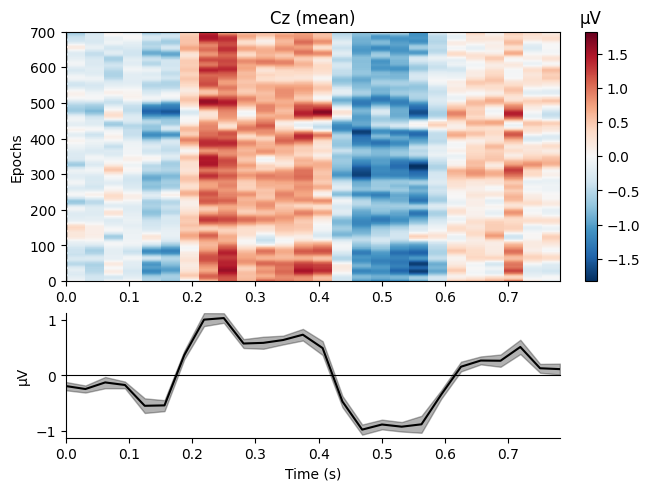

No projector specified for this dataset. Please consider the method self.add_proj.


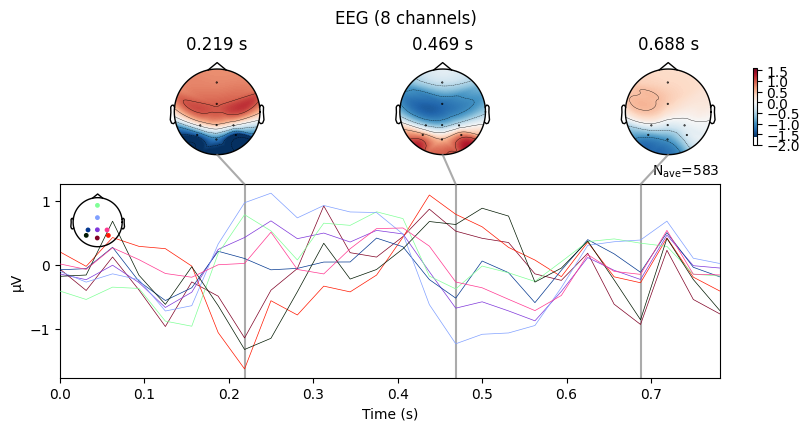

In [9]:
epochs_rec['Target'].plot_image(**image_args)
target_rec = epochs_rec['Target'].average()
non_target_rec = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target_rec,non_target_rec], weights=[1,-1])
_ = contrast_rec.plot_joint()

No projector specified for this dataset. Please consider the method self.add_proj.


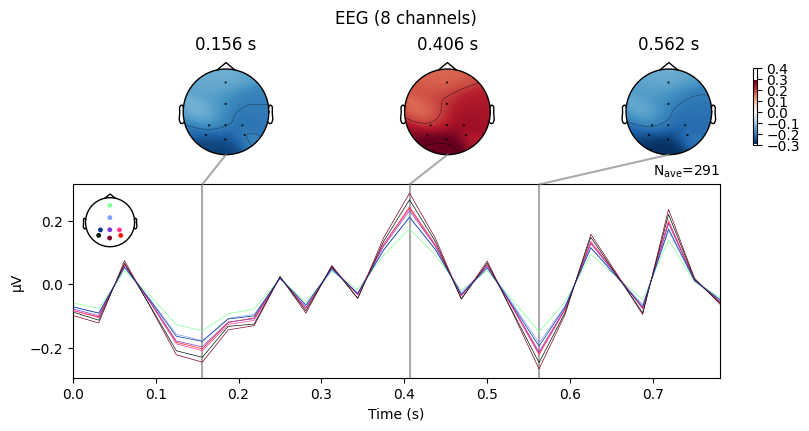

In [10]:
contrast_contrast_rec =  combine_evoked([contrast,contrast_rec], weights=[1,-1])
_ = contrast_contrast_rec.plot_joint(**joint_args)

In [25]:
Xt = bttda.transform(X)

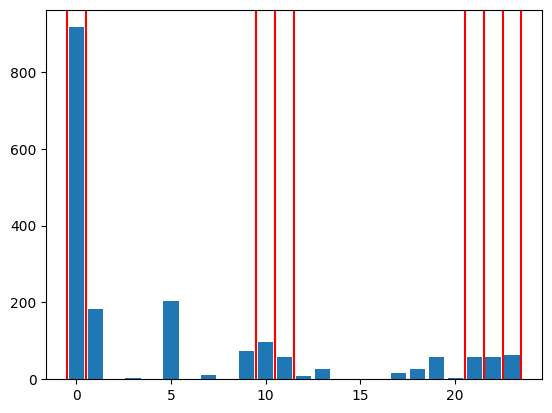

In [26]:
import scipy.stats
import seaborn as sns
import math

samples = []
for c in bttda.classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
plt.bar(np.arange(F.size),F.flatten())
n_params=0
plt.axvline(n_params-.5, color='red')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    plt.axvline(n_params-.5, color='red')


In [27]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA

order = np.argsort(-F.flatten())
Xt_viz = Xt.reshape((Xt.shape[0],-1))[:,order[:3]]
Xt_viz = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
if Xt_viz.shape[-1] > 3:
    decomp  = PCA(n_components=min(3, math.prod(Xt.shape[1:])))
    #decomp  = TSNE(n_components=min(3, math.prod(Xt.shape[1:])), n_jobs=-1)
    Xt_viz = decomp.fit_transform(Xt_viz)


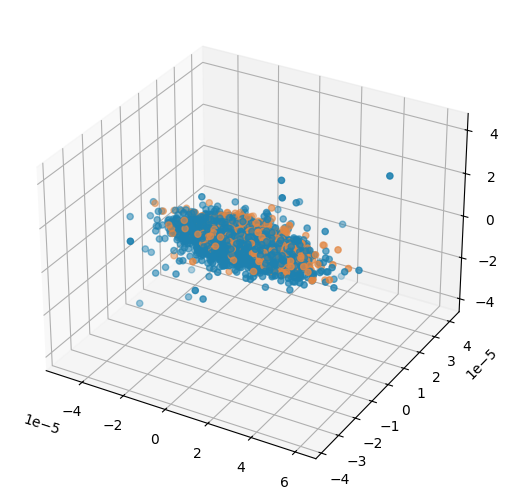

In [28]:
import re, seaborn as sns
import numpy as np

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

# axes instance
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)

cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
c = np.vectorize(cmap.get)(y)
sc = ax.scatter(Xt_viz[:,0],Xt_viz[:,1],Xt_viz[:,2], c=c)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

0.876390612244898


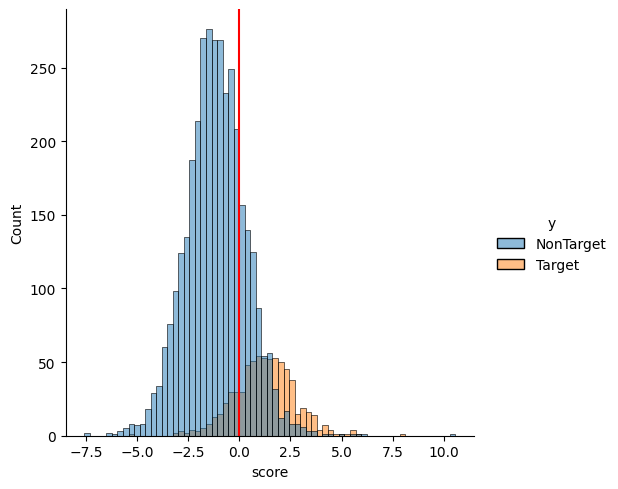

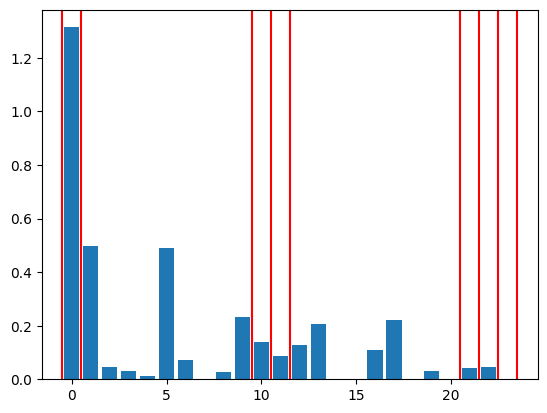

In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
Xt_flat = StandardScaler().fit_transform(Xt_flat)
logreg = LogisticRegressionCV(Cs=10, penalty='l1', solver='liblinear', class_weight='balanced', scoring='roc_auc', n_jobs=-1)
logreg.fit(Xt_flat, y)
score_pred = logreg.decision_function(Xt_flat)


df = pd.DataFrame(dict(score=score_pred,y=y))
g = sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))

fig, ax = plt.subplots(1,1)
_ = ax.bar(np.arange(Xt_flat.shape[1]), np.abs(logreg.coef_.squeeze()))
n_params=0
plt.axvline(n_params-.5, color='red')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    plt.axvline(n_params-.5, color='red')

In [30]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
color1 = (239, 85, 19)
color2 = (249, 193, 52)

cmap_res=256
vals = np.ones((cmap_res, 4))
for i in range(len(color1)):
    vals[:cmap_res//2,i] = np.linspace(1,color2[i]/256,cmap_res//2)[::-1]
    vals[cmap_res//2:,i] = np.linspace(1,color1[i]/256,cmap_res//2)

cmap_div = ListedColormap(vals)

vals = np.ones((cmap_res, 4))
for i in range(len(color1)):
    vals[:,i] = np.linspace(1,color1[i]/256,cmap_res)
cmap_lin = ListedColormap(vals)
darkgray = (.3,.3,.3)

RuntimeError: 'xelatex' not found; install it or change rcParams['pgf.texsystem'] to an available TeX implementation

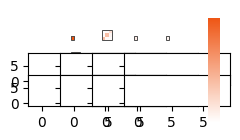

In [31]:
import math
from matplotlib.patches import Rectangle
p = 0
n_blocks = 16
col_wrap=4
n_rows = n_blocks//col_wrap
fig, axs= plt.subplots(col_wrap,n_rows, sharex=True, sharey=True)
axs = axs.flatten()
vmax = np.max(np.abs(logreg.coef_[:n_blocks]))
for bi,b in enumerate(bttda.blocks_[:n_blocks]):
    shape = b.rank_
    n_param = math.prod(shape)
    coef = logreg.coef_[:,p:p+n_param]
    p+=n_param
    coef = np.abs(coef.reshape(shape))
    im = axs[bi].imshow(coef, vmin=0, vmax=vmax, cmap=cmap_lin)
    axs[bi].set_xlim([-1,7])
    axs[bi].set_ylim([-1,9])
    axs[bi].set_axis_off()
    axs[bi].add_patch(Rectangle((-.5,-.5), shape[1], shape[0], edgecolor = darkgray,
             fill=False,linewidth=.7))
    axs[bi].set_aspect('equal')
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar_ax.set_axis_off()
fig.colorbar(im, cax=cbar_ax)
fig.set_size_inches(5*0.5,3*0.5)
fig.tight_layout()
fig.subplots_adjust(wspace=-.7, hspace=-.3)
fig.savefig('feature_importance.pgf', bbox_inches='tight', pad_inches=0, dpi=1000)

In [ ]:
fig, ax = plt.subplots(1,1)
ax.plot(bttda.train_info_['mse'], color='#ef5513')
ax.set_xlabel('Number of blocks')
ax.set_ylabel('MSE')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0,64])
ax.set_xticks([0,32,64])
ax.set_ylim([0,None])


ax.xaxis.label.set_color(darkgray)        #setting up X-axis label color to yellow
ax.yaxis.label.set_color(darkgray)         #setting up Y-axis label color to blue
ax.tick_params(axis='x', colors=darkgray)    #setting up X-axis tick color to red
ax.tick_params(axis='y', colors=darkgray)  #setting up Y-axis tick color to black
ax.spines['left'].set_color(darkgray)        # setting up Y-axis tick color to red
ax.spines['bottom'].set_color(darkgray) 

fig.set_size_inches(5*0.5,3*0.5)


fig.savefig('mse.pgf', bbox_inches='tight', pad_inches=0)